# Real DES data: look, cut, save

Turns the downloaded DES Y6 Gold strips into the small table the rest of this
project reads. Every cell is meant to be run and looked at, not trusted.

**What is already done**, by `scripts/fetch_des_dr2.py` — see `manifest.json`
beside the data, which records the exact SQL:

- stars are `0 <= EXT_XGB <= 1`, the selection streamobs's DES Y6 model
  reproduces, so the real catalogue and the injected streams are one sample
- `flags_footprint = 1`, `flags_foreground = 0`, `flags_gold = 0`
- extinction applied (the `_corrected` PSF magnitudes)
- magnitudes 15.5 to 25, errors better than 0.54 mag (signal-to-noise above 2)

**What is left to this notebook**: the signal-to-noise cut, the 16 to 24.5
clip the trained models assume, and writing the four columns the pipeline
reads.

| column | meaning |
|---|---|
| `ra`, `dec` | degrees |
| `des_yr6_g_obs`, `des_yr6_r_obs` | magnitudes, extinction applied, cut and clipped |

The namespace `des_yr6` comes from `SURVEY`/`RELEASE` in the stream-parameters
experiment (`streamobs.columns.obs_col`); change those and this name changes.

## 1. Load the strips

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

DATA = Path("~/Documents/data/DES_yr6").expanduser()

manifest = json.loads((DATA / "manifest.json").read_text())
print(manifest["description"])
print(f"\n{manifest['totals']['rows']:,} stars in "
      f"{manifest['totals']['files']} strips "
      f"({manifest['totals']['bytes'] / 1e9:.2f} GB)")
print("\nselection already applied:")
for key, value in manifest["selection"].items():
    if key != "sql_where":
        print(f"  {key}: {value}")

DES DR2 point sources for the streamgoggles stream search. One parquet file per one-degree declination strip; concatenate them for the full footprint.

49,068,865 stars in 75 strips (1.70 GB)

selection already applied:
  star_galaxy: ext_xgb BETWEEN 0 AND 1 -- 0 <= EXT_XGB <= 1 is the selection streamobs's DES Y6 model reproduces, so the real catalogue and the injected streams are the same sample. ext_coadd and ext_mash are stored for diagnostics but do not define the sample; the union of those two misses 14.6% of EXT_XGB stars.
  quality: flags_footprint = 1, flags_foreground = 0, flags_gold = 0. flags_foreground is the reason to prefer Gold: it removes bright-star haloes and nearby galaxies, which are what fake a localized overdensity.
  signal_to_noise: > 2 in both g and r (a floor, not the analysis cut: choose that downstream, the errors are kept)
  magnitudes: 15.5 to 25.0 dereddened in both bands, wider than the pipeline's 16 to 24.5 clip on purpose
  extinction: already applied

In [2]:
# Only the columns needed here; ext_coadd and ext_mash stay on disk as
# diagnostics. DEC_RANGE = None reads the whole footprint: about 49 million
# stars, roughly 1.6 GB in memory, so close other notebooks first.
COLUMNS = ["ra", "dec", "g", "r", "g_err", "r_err"]
DEC_RANGE = None                # or e.g. (-60, -40) for one band of sky

strips = sorted(DATA.glob("des_y6gold_dec*.parquet"))
if DEC_RANGE is not None:
    low, high = DEC_RANGE
    strips = [s for s in strips if low <= float(s.stem.split("dec")[1]) < high]

# Strips outside the footprint hold zero rows. Reading them is harmless but
# concatenating them is not, if their columns were ever written with parquet
# type "null": that promotes ra and dec to object and every later cast fails.
frames = [pd.read_parquet(s, columns=COLUMNS) for s in strips]
frames = [f for f in frames if len(f)]
raw = pd.concat(frames, ignore_index=True).astype(
    {"ra": "float64", "dec": "float64"}
)
print(f"{len(raw):,} stars from {len(frames)} non-empty strips "
      f"({raw.memory_usage(deep=True).sum() / 1e9:.2f} GB)")
raw.describe().T[["count", "mean", "min", "max"]]

49,068,865 stars from 73 non-empty strips (1.57 GB)


,count,mean,min,max
ra,49068865.0,139.624755,0.000101,359.999926
dec,49068865.0,-37.099027,-67.445756,4.999987
g,49068865.0,22.548441,15.500396,25.000000
r,49068865.0,21.625275,15.500000,25.000000
g_err,49068865.0,0.054204,0.000112,0.542816
r_err,49068865.0,0.030563,0.000103,0.542427


In [3]:
print(raw.columns)

Index(['ra', 'dec', 'g', 'r', 'g_err', 'r_err'], dtype='str')


## 2. Where it is on the sky

Look for holes, the survey edge, and density gradients. The foreground mask is
already applied, so the small empty discs are removed bright stars — those are
supposed to be there.

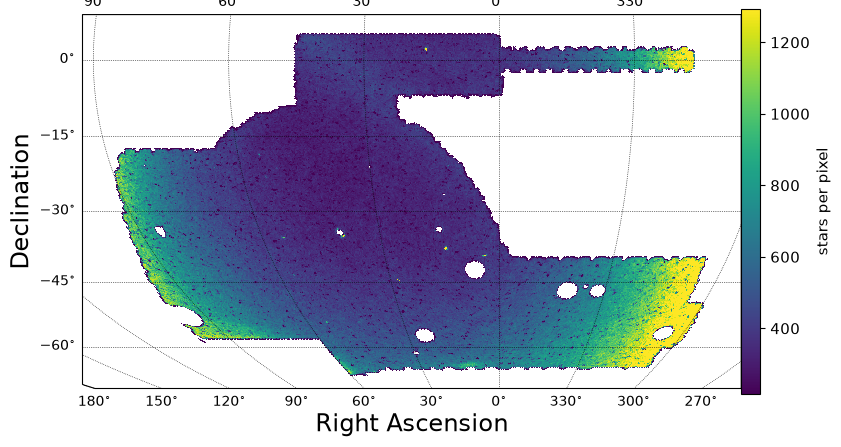

In [4]:
import matplotlib.pyplot as plt
import skyproj

fig, ax = plt.subplots(figsize=(10, 5))
sp = skyproj.McBrydeSkyproj(ax=ax)
sp.draw_hpxbin(raw["ra"].to_numpy(), raw["dec"].to_numpy(), nside=256)
sp.draw_colorbar(label="stars per pixel")
ax.set_title("EXT_XGB stars, before the magnitude and signal-to-noise cuts")
plt.show()

## 3. Colour-magnitude space

The stellar locus should be tight — these are already classified as point
sources. Where the counts turn over is the real depth.

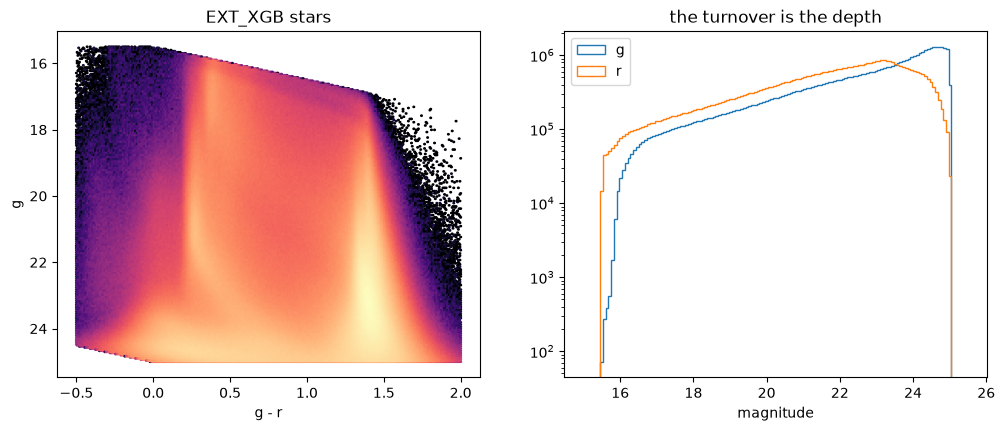

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hexbin(raw["g"] - raw["r"], raw["g"], gridsize=250,
               extent=(-0.5, 2.0, 15.5, 25), bins="log", cmap="magma")
axes[0].invert_yaxis()
axes[0].set_xlabel("g - r"); axes[0].set_ylabel("g")
axes[0].set_title("EXT_XGB stars")
for band in ("g", "r"):
    axes[1].hist(raw[band], bins=140, range=(15, 25.5), histtype="step", label=band)
axes[1].set_yscale("log"); axes[1].set_xlabel("magnitude"); axes[1].legend()
axes[1].set_title("the turnover is the depth")
plt.show()

## 4. Where the signal-to-noise cut bites

`sigma_m = 1.0857 / SNR`. Read off the magnitude where the threshold line
crosses the bulk of the stars: **that, not the 24.5 clip, is your real depth**.
streamobs's DES Y6 model is anchored at a signal-to-noise of 5 with median
depth g = 25.025, r = 24.850, so a cut well brighter than that is leaving
usable stars behind — and whatever is chosen here has to be applied to the
simulated catalogue too, or the two samples stop being comparable.

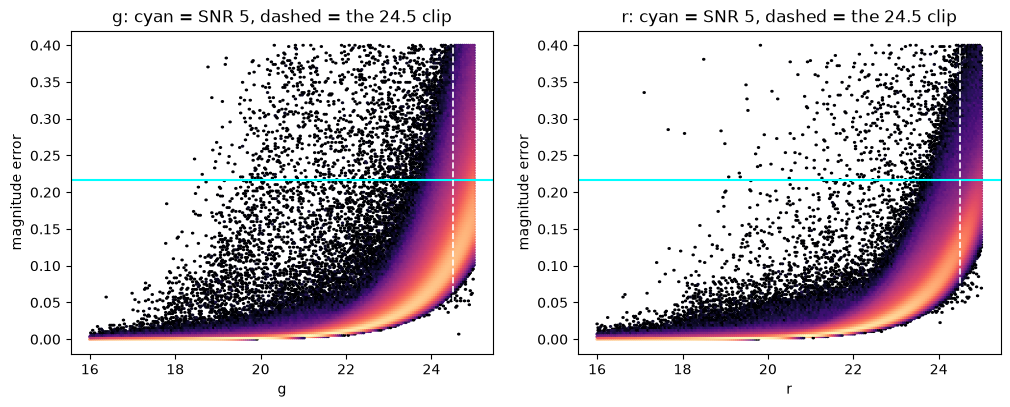

In [6]:
SNR_MIN = 5.0
MAX_MAGERR = 1.0857 / SNR_MIN

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, band in zip(axes, ["g", "r"]):
    ax.hexbin(raw[band], raw[f"{band}_err"], gridsize=200,
              extent=(16, 25, 0, 0.4), bins="log", cmap="magma")
    ax.axhline(MAX_MAGERR, color="cyan", lw=1.5)
    ax.axvline(24.5, color="white", ls="--", lw=1.2)
    ax.set_xlabel(band); ax.set_ylabel("magnitude error")
    ax.set_title(f"{band}: cyan = SNR {SNR_MIN:g}, dashed = the 24.5 clip")
plt.show()

## 5. Cut

In [7]:
CLIP = {"g": (16.0, 24.5), "r": (16.0, 24.5)}

masks = {
    f"SNR > {SNR_MIN:g}": (raw["g_err"] < MAX_MAGERR) & (raw["r_err"] < MAX_MAGERR),
    "magnitude clip": (
        raw["g"].between(*CLIP["g"]) & raw["r"].between(*CLIP["r"])
    ),
}
for name, mask in masks.items():
    print(f"  {name:<16} keeps {100 * mask.mean():5.1f}% on its own")

keep = np.logical_and.reduce(list(masks.values()))
print(f"\ntogether: {keep.sum():,} of {len(raw):,} ({100 * keep.mean():.1f}%)")

cut = pd.DataFrame({
    "ra": raw.loc[keep, "ra"].to_numpy(),
    "dec": raw.loc[keep, "dec"].to_numpy(),
    "des_yr6_g_obs": raw.loc[keep, "g"].to_numpy(),
    "des_yr6_r_obs": raw.loc[keep, "r"].to_numpy(),
})
cut.head()

  SNR > 5          keeps  99.1% on its own
  magnitude clip   keeps  81.8% on its own

together: 40,111,394 of 49,068,865 (81.7%)


,ra,dec,des_yr6_g_obs,des_yr6_r_obs
0,340.306772,0.000000,23.129404,21.795870
1,25.775540,0.000000,22.434099,21.343540
2,321.433840,0.000001,24.356176,24.414629
3,16.283922,0.000002,21.464815,20.047134
4,321.909263,0.000004,23.798435,22.321386


## 6. The same two plots again

The locus should be unchanged in shape and simply truncated at the faint end.
If the density map grew new structure, the cut is interacting with the depth
variation across the footprint — which matters, because a detector reads that
structure as signal.

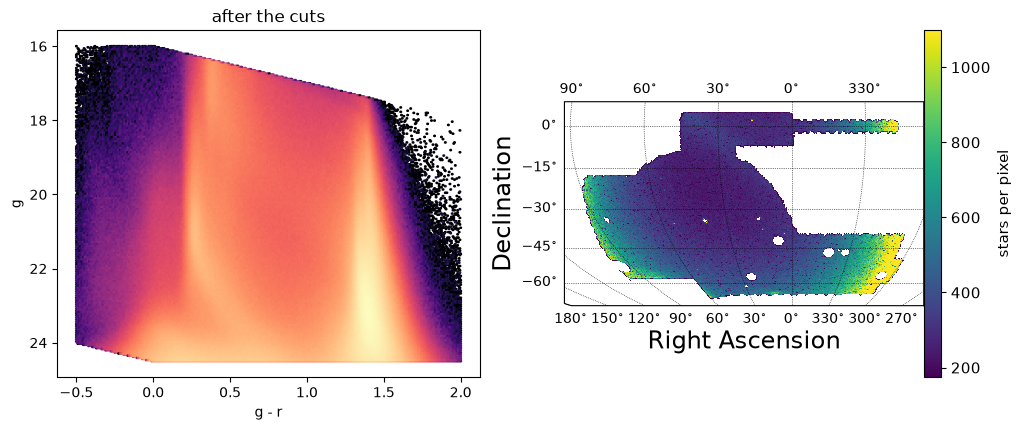

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hexbin(cut["des_yr6_g_obs"] - cut["des_yr6_r_obs"], cut["des_yr6_g_obs"],
               gridsize=250, extent=(-0.5, 2.0, 16, 24.5), bins="log", cmap="magma")
axes[0].invert_yaxis(); axes[0].set_xlabel("g - r"); axes[0].set_ylabel("g")
axes[0].set_title("after the cuts")
sp = skyproj.McBrydeSkyproj(ax=axes[1])
sp.draw_hpxbin(cut["ra"].to_numpy(), cut["dec"].to_numpy(), nside=256)
sp.draw_colorbar(label="stars per pixel")
axes[1].set_title("density after the cuts")
plt.show()

## 7. Mask the known streams

The background for injection has to be free of real streams, or the model
learns to call them background. Tracks come from `galstreams`; the widths come
from this project's own Shipp et al. (2018) table, so the mask and the
injected analogues describe the streams the same way.

`galstreams.MWStreams()` raises an `IndexError` against astropy 8, so the
shipped track files are read directly. They come in two shapes and both are
already densified: `track.st.*` are measured tracks, `track.ep.*` are the
Shipp et al. endpoint pairs interpolated to 200 points.

**Sagittarius is masked too**, as in the DES 2018 analysis — nobody is
searching for cold streams inside it. But it needs its own width factor: its
quoted 6 degrees is the extent of a broad structure, not a Gaussian sigma, so
tripling it would mask 27% of the footprint on its own. Anything wider than
`WIDE_STREAM_DEG` therefore gets `WIDE_STREAM_FACTOR` instead.

**Every reference is unioned per stream, which is worth watching.** Jhelum is
the cautionary case: `galstreams` carries six tracks for it, from 13 to
**95.6 degrees** long, because Ibata 2024 traces it three times further than
the DES-era measurements. Unioning them makes Jhelum alone 14.1% of the
footprint — more than half the whole DES 2018 mask. The per-stream table
below exists so that kind of surprise is visible rather than buried; use
`EXCLUDE_TRACKS` to drop a track you do not believe.

In [9]:
import astropy.units as u
import galstreams
import healpy as hp
from astropy.coordinates import SkyCoord
from astropy.table import Table

NSIDE = 512                 # the pipeline's resolution
STREAM_SET = "des2018"      # or "all"
WIDTH_FACTOR = 3.0          # mask out to this many times the quoted width
WIDE_STREAM_DEG = 2.0       # a stream wider than this is a broad structure...
WIDE_STREAM_FACTOR = 1.0    # ...so its quoted width is already its extent
DEFAULT_WIDTH = 0.5         # degrees, when no width is published
EXTRA_STREAMS = {"Sagittarius": 6.0}   # masked as well, with its own width
EXCLUDE_TRACKS = set()      # e.g. {"Jhelum.ibata2024"} to drop one reference

import importlib.util as _u
_spec = _u.spec_from_file_location("sp_run", "../scripts/experiments/stream_parameters/run.py")
run = _u.module_from_spec(_spec); _spec.loader.exec_module(run)

# galstreams names that differ from the DES 2018 paper's. Chenab and Palca map
# to the larger structures they belong to, which is what should be masked.
GALSTREAMS_NAME = {
    "Tucana III": "TucanaIII", "ATLAS": "AAU-ATLAS", "Aliqa Uma": "AAU-AliqaUma",
    "Willka Yaku": "Willka_Yaku", "Chenab": "Orphan-Chenab",
}
GS = Path(galstreams.__file__).parent
track_files = [
    f for f in GS.glob("tracks/track.??.*.ecsv")
    if "summary" not in f.name
    and ".".join(f.name.split(".")[2:4]) not in EXCLUDE_TRACKS
]

def tracks_for(name):
    """Every galstreams track file for one stream, across references."""
    gname = GALSTREAMS_NAME.get(name, name.replace(" ", "_"))
    return [f for f in track_files if f".{gname}." in f.name]

def factor_for(width):
    """A broad structure's quoted width is its extent, not a sigma."""
    return WIDE_STREAM_FACTOR if width >= WIDE_STREAM_DEG else WIDTH_FACTOR

if STREAM_SET == "des2018":
    wanted = {n: w for n, (w, _, _, _) in run.DES_STREAMS.items()}
else:
    log = Table.read(GS / "lib/master_log.txt", format="ascii.commented_header")
    published = {}
    for row in log:
        if float(row["width_phi2"]) > 0:
            published[str(row["Name"])] = max(
                published.get(str(row["Name"]), 0.0), float(row["width_phi2"])
            )
    wanted = {f.name.split(".")[2]: published.get(f.name.split(".")[2], DEFAULT_WIDTH)
              for f in track_files}
wanted.update(EXTRA_STREAMS)

print(f"{'stream':<16}{'width':>7}{'factor':>8}{'files':>7}{'longest track':>15}")
for name, width in sorted(wanted.items()):
    files = tracks_for(name)
    longest = 0.0
    for f in files:
        t = Table.read(f)
        ra = np.asarray(t["ra"].value, float); dec = np.asarray(t["dec"].value, float)
        c = SkyCoord(ra * u.deg, dec * u.deg)
        longest = max(longest, float(c[:-1].separation(c[1:]).deg.sum()))
    print(f"{name:<16}{width:7.2f}{factor_for(width):8.1f}{len(files):7d}"
          f"{longest:14.1f}°")

stream            width  factor  files  longest track
ATLAS              0.24     3.0      3          40.8°
Aliqa Uma          0.26     3.0      1           9.7°
Chenab             0.71     3.0      4         230.6°
Elqui              0.54     3.0      1          10.9°
Indus              0.83     3.0      2          90.3°
Jhelum             1.16     3.0      2          95.6°
Molonglo           0.32     3.0      1          19.4°
Phoenix            0.16     3.0      2          17.9°
Ravi               0.72     3.0      1          16.6°
Sagittarius        6.00     1.0      1         280.0°
Tucana III         0.18     3.0      2          17.0°
Turbio             0.25     3.0      1          15.0°
Turranburra        0.60     3.0      1          13.7°
Wambelong          0.40     3.0      1          14.2°
Willka Yaku        0.21     3.0      1           6.4°


### The tracks on the data

Each track drawn over the observed density. Anything running through a visible
overdensity is doing its job; anything far off the data is a stream that misses
this footprint and will contribute nothing to the mask.

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/skyproj/_skyproj.py:621: FutureWarning: skyproj.plot() has been deprecated and will be removed in v2.5. Please access via skyproj.ax.plot()
  warnings.warn(
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/skyproj/_skyproj.py:621: FutureWarning: skyproj.plot() has been deprecated and will be removed in v2.5. Please access via skyproj.ax.plot()
  warnings.warn(
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/skyproj/_skyproj.py:621: FutureWarning: skyproj.plot() has been deprecated and will be removed in v2.5. Please access via skyproj.ax.plot()
  warnings.warn(
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/skyproj/_skyproj.py:621: FutureWarning: skyproj.plot() has been deprecated and will be removed in v2.5. Please access via skyproj.ax.plot()
  warnings.warn(
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/skyproj/_skyproj.py:621: FutureWarning: skyproj.plot() has been deprecated and wil

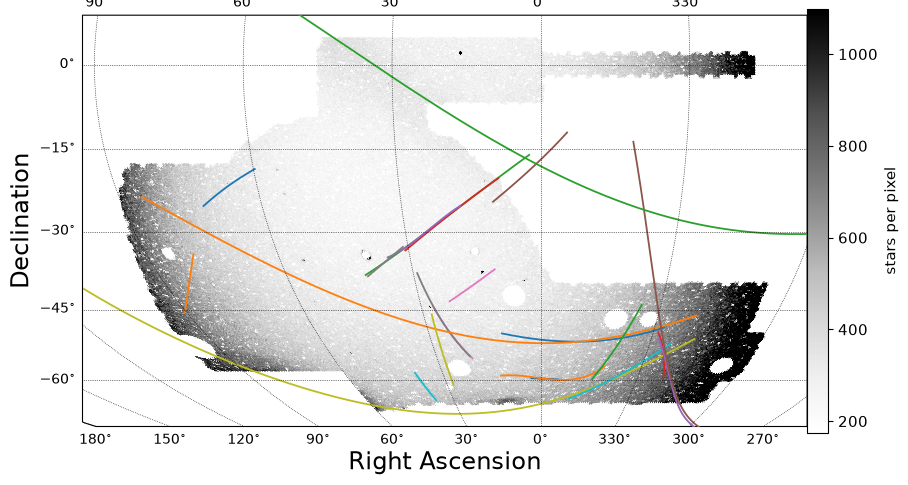

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))
sp = skyproj.McBrydeSkyproj(ax=ax)
sp.draw_hpxbin(cut["ra"].to_numpy(), cut["dec"].to_numpy(), nside=256, cmap="Greys")
sp.draw_colorbar(label="stars per pixel")

star_pix = hp.ang2pix(NSIDE, cut["ra"].to_numpy(), cut["dec"].to_numpy(), lonlat=True)
covered = np.zeros(hp.nside2npix(NSIDE), dtype=bool)
covered[np.unique(star_pix)] = True

crossing = []
for name in wanted:
    for f in tracks_for(name):
        track = Table.read(f)
        ra = np.asarray(track["ra"].value, float)
        dec = np.asarray(track["dec"].value, float)
        if not covered[hp.ang2pix(NSIDE, ra, dec, lonlat=True)].any():
            continue
        crossing.append(name)
        sp.plot(ra, dec, lw=1.3)
        middle = len(ra) // 2
        ax.annotate(name, (ra[middle], dec[middle]), fontsize=6,
                    xycoords=sp.ax.transData, alpha=0.8)
ax.set_title(f"{len(set(crossing))} known streams cross this footprint")
plt.show()

### The mask itself

A pixel is masked if it lies within `WIDTH_FACTOR` times the stream's width of
any point on its track.

In [11]:
pixel_area = hp.nside2pixarea(NSIDE, degrees=True)
mask = np.zeros(hp.nside2npix(NSIDE), dtype=bool)
per_stream = {}
for name, width in wanted.items():
    radius = np.radians(factor_for(width) * width)
    one = np.zeros_like(mask)
    for f in tracks_for(name):
        track = Table.read(f)
        ra = np.asarray(track["ra"].value, float)
        dec = np.asarray(track["dec"].value, float)
        vectors = hp.ang2vec(ra, dec, lonlat=True)
        # Every few hundred points is enough: consecutive discs of this radius
        # overlap heavily, so sampling the track costs nothing in coverage.
        for vector in vectors[:: max(1, len(vectors) // 600)]:
            one[hp.query_disc(NSIDE, vector, radius)] = True
    if one.any():
        per_stream[name] = 100 * (one & covered).sum() / covered.sum()
        mask |= one

inside = mask & covered
removed = mask[star_pix]
print("share of the footprint each stream costs (they overlap, so these sum high):")
for name, share in sorted(per_stream.items(), key=lambda kv: -kv[1]):
    print(f"   {name:<16}{share:5.1f}%")
print(f"\n{len(per_stream)} streams masked")
print(f"  footprint:     {covered.sum() * pixel_area:8,.0f} deg^2")
print(f"  masked:        {inside.sum() * pixel_area:8,.0f} deg^2 "
      f"({100 * inside.sum() / covered.sum():.1f}%)")
print(f"  stars removed: {removed.sum():,} of {len(cut):,} ({100 * removed.mean():.1f}%)")

share of the footprint each stream costs (they overlap, so these sum high):
   Jhelum           14.1%
   Sagittarius       6.4%
   Indus             4.2%
   Chenab            2.5%
   Ravi              1.6%
   Turranburra       1.2%
   ATLAS             1.1%
   Elqui             0.9%
   Wambelong         0.8%
   Turbio            0.5%
   Tucana III        0.4%
   Phoenix           0.4%
   Aliqa Uma         0.3%
   Willka Yaku       0.2%
   Molonglo          0.1%

15 streams masked
  footprint:        5,025 deg^2
  masked:           1,582 deg^2 (31.5%)
  stars removed: 13,208,188 of 40,111,394 (32.9%)


### Globular clusters and dwarf galaxies

The same argument as for streams, for the same reason: both are real stellar
overdensities that are already catalogued, so a detector should never be asked
about them — not in training, where they would be learned as background, and
not in evaluation, where finding one is neither a hit nor a false alarm.

Catalogues come from `streamgoggles.objects_overlap`, which reads them from
the package rather than over the network, and the footprint they are matched
against is the packaged DES one. Each object is masked to
`OBJECT_RADIUS_FACTOR` half-light radii, with a floor for the many rows whose
`rhalf` is missing or zero.

In [12]:
from streamgoggles.objects_overlap import (
    get_dwarf_within_footprint,
    get_GC_within_footprint,
    mask_objects,
)

OBJECT_RADIUS_FACTOR = 5.0   # half-light radii
OBJECT_MIN_RADIUS = 0.05     # degrees, for objects with no published size

clusters, clusters_in = get_GC_within_footprint(footprint="des_yr6")
dwarfs, dwarfs_in = get_dwarf_within_footprint(footprint="des_yr6")

cluster_mask, cluster_radii = mask_objects(
    clusters, clusters_in, nside=NSIDE,
    radius_factor=OBJECT_RADIUS_FACTOR, min_radius_deg=OBJECT_MIN_RADIUS,
)
dwarf_mask, dwarf_radii = mask_objects(
    dwarfs, dwarfs_in, nside=NSIDE,
    radius_factor=OBJECT_RADIUS_FACTOR, min_radius_deg=OBJECT_MIN_RADIUS,
)
object_mask = cluster_mask | dwarf_mask

print(f"in the DES footprint: {clusters_in.sum()} globular clusters, "
      f"{dwarfs_in.sum()} dwarf galaxies")
print(f"  masking radii: {cluster_radii.min():.2f}-{cluster_radii.max():.2f} deg "
      f"(clusters), {dwarf_radii.min():.2f}-{dwarf_radii.max():.2f} deg (dwarfs)")
print(f"  costs {(object_mask & covered).sum() * pixel_area:,.1f} deg^2 "
      f"({100 * (object_mask & covered).sum() / covered.sum():.2f}% of the footprint)")
print("\nthe five largest:")
biggest = sorted(
    [(str(r["name"]), 5 * float(r["rhalf"]) / 60) for r in dwarfs[dwarfs_in]]
    + [(str(r["name"]), 5 * float(r["rhalf"]) / 60) for r in clusters[clusters_in]],
    key=lambda x: -x[1],
)[:5]
for name, radius in biggest:
    print(f"   {name:<20}{radius:5.2f} deg")

in the DES footprint: 3 globular clusters, 49 dwarf galaxies
  masking radii: 0.05-0.09 deg (clusters), 0.05-1.07 deg (dwarfs)
  costs 12.2 deg^2 (0.24% of the footprint)

the five largest:
   Tucana II            1.07 deg
   Tucana IV            0.78 deg
   IC 1613              0.63 deg
   Reticulum II         0.53 deg
   NGC 55-dw1           0.43 deg


/var/folders/9j/zk4h50g505d635j69p9tgwbc0000gp/T/ipykernel_75960/974258702.py:31: UserWarning: Warning: converting a masked element to nan.
  [(str(r["name"]), 5 * float(r["rhalf"]) / 60) for r in dwarfs[dwarfs_in]]


### The objects on their own

Three panels, because 49 small discs on a full-sky projection are invisible
otherwise. Left: where they sit in the footprint, sized by the radius actually
masked. Middle: the object mask by itself, at the resolution the pipeline
uses. Right: the largest object close up, to see how the masked disc compares
with the stars it is covering.

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/skyproj/_skyproj.py:629: FutureWarning: skyproj.scatter() has been deprecated and will be removed in v2.5. Please access via skyproj.ax.scatter()
  warnings.warn(
/var/folders/9j/zk4h50g505d635j69p9tgwbc0000gp/T/ipykernel_75960/2532970460.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower left", fontsize=8)


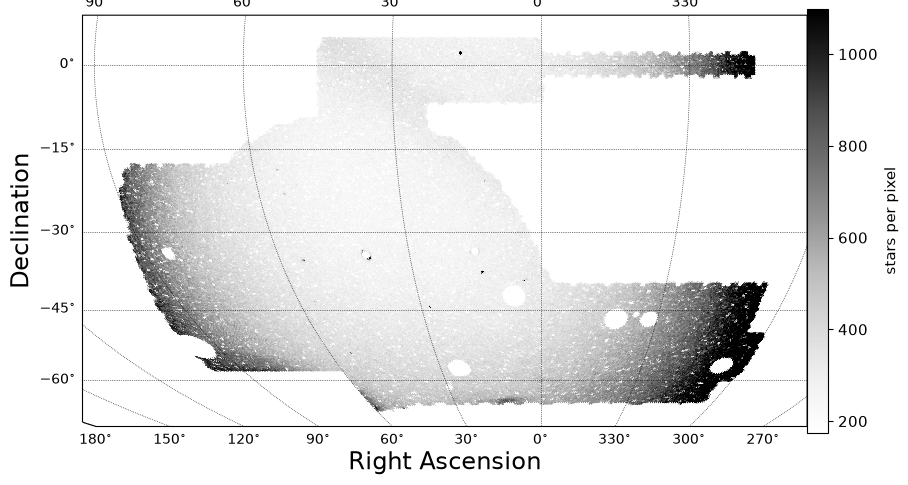

In [13]:
objects = pd.DataFrame(
    [(str(r["name"]), float(r["ra"]), float(r["dec"]),
      max(OBJECT_RADIUS_FACTOR * float(r["rhalf"]) / 60, OBJECT_MIN_RADIUS), kind)
     for table, inside_it, kind in [(dwarfs, dwarfs_in, "dwarf"),
                                    (clusters, clusters_in, "cluster")]
     for r in table[inside_it]],
    columns=["name", "ra", "dec", "radius", "kind"],
).sort_values("radius", ascending=False)
print(objects.head(10).to_string(index=False))

fig = plt.figure(figsize=(16, 4.6))

# Left: positions over the density, marker area following the masked radius.
ax = fig.add_subplot(1, 3, 1)
sp = skyproj.McBrydeSkyproj(ax=ax)
sp.draw_hpxbin(cut["ra"].to_numpy(), cut["dec"].to_numpy(), nside=256, cmap="Greys")
for kind, colour in [("dwarf", "tab:red"), ("cluster", "tab:blue")]:
    rows = objects[objects.kind == kind]
    sp.scatter(rows.ra.to_numpy(), rows.dec.to_numpy(),
               s=20 + 400 * rows.radius.to_numpy(), facecolors="none",
               edgecolors=colour, linewidths=1.3, label=f"{kind}s ({len(rows)})")
ax.legend(loc="lower left", fontsize=8)
ax.set_title("catalogued objects in the footprint", fontsize=10)

# Middle: the mask itself, so the discs are actually visible.
ax = fig.add_subplot(1, 3, 2)
sp = skyproj.McBrydeSkyproj(ax=ax)
shown = np.flatnonzero(object_mask & covered)
sp.draw_hpxpix(NSIDE, shown, np.ones(shown.size), cmap="Reds", vmin=0, vmax=1)
ax.set_title(f"the object mask: {len(objects)} discs, "
             f"{(object_mask & covered).sum() * pixel_area:,.1f} deg^2", fontsize=10)

# Right: the largest one, with the stars it covers and the masked circle.
ax = fig.add_subplot(1, 3, 3)
biggest = objects.iloc[0]
window = 2.5 * biggest.radius
near = cut[(np.abs(cut.ra - biggest.ra) < window / np.cos(np.radians(biggest.dec)))
           & (np.abs(cut.dec - biggest.dec) < window)]
ax.scatter(near.ra, near.dec, s=1, alpha=0.25, color="0.4")
circle = plt.Circle((biggest.ra, biggest.dec), biggest.radius, fill=False,
                    color="tab:red", lw=2)
ax.add_patch(circle)
ax.set_aspect(1 / np.cos(np.radians(biggest.dec)))
ax.set_xlabel("RA (deg)"); ax.set_ylabel("Dec (deg)")
ax.set_title(f"{biggest['name']}: {biggest.radius:.2f} deg masked", fontsize=10)
plt.tight_layout()
plt.show()

### What is masked, and what is left

Left: the stars the mask removes, with the tracks on top — they should form
ribbons, not blobs. Right: the background that remains, which is what streams
get injected into. Check the right panel for ribbon-shaped holes: those are
the masked streams, and their edges are where a residual stream would hide.

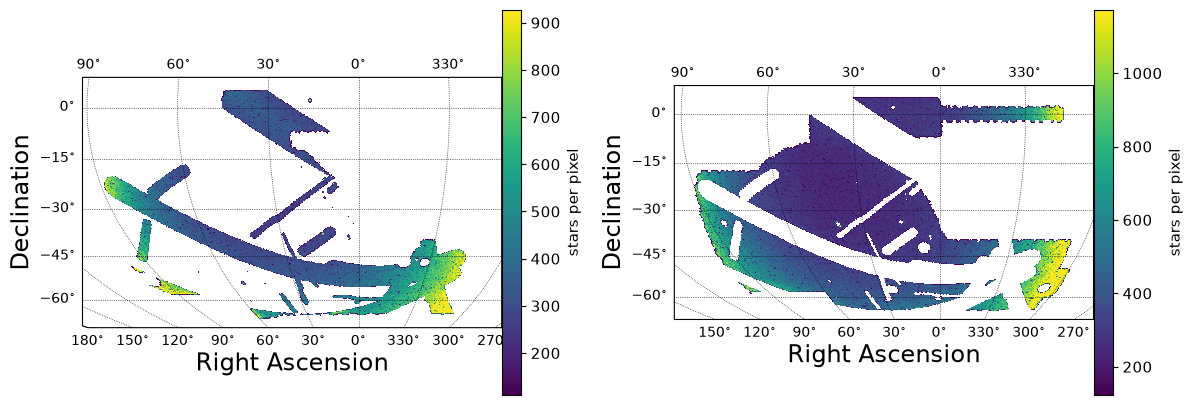

In [14]:
# Streams and objects together: the background is what neither touches.
removed = (mask | object_mask)[star_pix]
background = cut[~removed].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (sel, title) in zip(axes, [
    (removed, f"removed: {removed.sum():,} stars"),
    (~removed, f"kept as background: {(~removed).sum():,} stars"),
]):
    sp = skyproj.McBrydeSkyproj(ax=ax)
    sp.draw_hpxbin(cut["ra"].to_numpy()[sel], cut["dec"].to_numpy()[sel], nside=256)
    sp.draw_colorbar(label="stars per pixel")
    ax.set_title(title)
plt.show()

## 8. Save the background

Four columns, which is all the injection and background code reads. The
sidecar records both what the download already applied and what this notebook
did, including which streams were masked -- a later reader should not have to
guess whether this table still contains real streams.

In [15]:
OUT = DATA / "des_yr6_background.parquet"
background.to_parquet(OUT, index=False)
(DATA / "des_yr6_background.json").write_text(json.dumps({
    "description": (
        "Stream-free DES Y6 Gold background for the streamgoggles injection "
        "pipeline: known streams masked, so an injected stream is the only "
        "stream present."
    ),
    "built_from": manifest["source"],
    "inherited_selection": manifest["selection"],
    "applied_here": {
        "signal_to_noise": f"> {SNR_MIN:g} in both bands",
        "magnitude_clip": {k: list(v) for k, v in CLIP.items()},
        "dec_range": DEC_RANGE,
        "stream_mask": {
            "source": "galstreams tracks, widths from Shipp et al. (2018)",
            "set": STREAM_SET,
            "width_factor": WIDTH_FACTOR,
            "streams": {name: round(share, 2) for name, share in sorted(per_stream.items())},
            "streams_note": "name -> percent of footprint masked",
            "stars_removed": int(removed.sum()),
        },
        "object_mask": {
            "source": "streamgoggles.objects_overlap (packaged catalogues)",
            "radius_factor": OBJECT_RADIUS_FACTOR,
            "min_radius_deg": OBJECT_MIN_RADIUS,
            "globular_clusters": int(clusters_in.sum()),
            "dwarf_galaxies": int(dwarfs_in.sum()),
            "footprint_removed_percent": round(
                100 * float(inside.sum()) / float(covered.sum()), 2
            ),
        },
    },
    "columns": ["ra", "dec", "des_yr6_g_obs", "des_yr6_r_obs"],
    "rows": int(len(background)),
}, indent=2) + "\n")
print(f"{len(background):,} stars -> {OUT} ({OUT.stat().st_size / 1e6:.0f} MB)")

NameError: name 'masked_streams' is not defined

## 9. Does the pipeline accept it?

The real test of the contract: build one matched-filter map from this table
with the experiment's own filter. If this runs and the map has counts in it,
the file is usable as a background everywhere else.

In [ ]:
import importlib.util as u

spec = u.spec_from_file_location("sp_run", "../scripts/experiments/stream_parameters/run.py")
run = u.module_from_spec(spec); spec.loader.exec_module(run)

from streamgoggles.background import build_raw_background_maps
from streamgoggles.matched_filter import PixelizationSpec, build_matched_filters

pix = PixelizationSpec(nside=512, image_size_pix=(96, 96))
filters = build_matched_filters(run.FILTERS, namespace=f"{run.SURVEY}_{run.RELEASE}")
maps = build_raw_background_maps(
    catalog=pd.read_parquet(OUT),
    matched_filters=filters,
    bands=["g", "r"],
    distance_moduli=[17.0],
    pix=pix,
)
raw_map, valid = maps["good"][17.0]
print(f"selected stars: {raw_map.sum():,.0f}")
print(f"covered pixels: {valid.sum():,} "
      f"(mean {raw_map[valid].mean():.2f} stars per pixel)")

selected stars: 1,006,388
covered pixels: 144,754 (mean 6.95 stars per pixel)
